# FGPA inversion from Lyα-forest mock spectra

This notebook constructs a one-dimensional Lyα-forest spectrum from simulated
**neutral-hydrogen density and temperature fields**, and then asks how much
of the gas-density field can be recovered with the fluctuating Gunn–Peterson
approximation (FGPA).


## Learning objectives

By the end of the notebook, a student should be able to:

1. distinguish the physical forward model from the approximate inverse model;
2. measure the low-density IGM temperature–density relation from a phase diagram;
3. derive and implement the FGPA relation
   $\tau=A(T_0/10^4\,{\rm K})^{-0.7}\Delta_b^\beta$;
4. explain why Voigt broadening makes the forward map non-local;
5. interpret saturated pixels as **lower limits**, not density measurements;
6. separate baryon reconstruction error from the additional gas-to-dark-matter
   tracing approximation; and
7. validate fields at a resolution supported by the observation.

### The controlled experiment

| Stage | Information used |
|---|---|
| Realistic mock | simulated $\rho_{\rm HI}(x)$, $T(x)$, Hubble mapping, Voigt profile, instrument, noise |
| FGPA calibration | independent mock skewers and the median $T$–$\Delta_b$ fit |
| FGPA inversion | flux, $A$, $T_0$, and $\gamma$ only |
| Validation only | true gas and dark-matter fields |

The true target density is never used as an input to its own reconstruction.

## 1. Imports and visual style

The implementation intentionally uses only NumPy, SciPy, and Matplotlib. Functions
are short, named after the physical operation they perform, and tested on one
skewer before being reused.

In [78]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from scipy import ndimage, special
from scipy.optimize import brentq

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "legend.frameon": False,
})

BLACK = "#202020"
BLUE = "#2474A6"
ORANGE = "#D97917"
PURPLE = "#6A51A3"
RED = "#C83E4D"
GREY = "#777777"

## 2. Configuration

The default observation is good enough that the inverse remains interpretable,
while still containing saturated pixels. All distances are comoving unless stated
otherwise.

In [79]:
# Data selection
data_directory = Path("Sims/CMD_z=2_grid128")
simulation_index = 0
sightline_index = 96       # use (y, z) = (96, 96)

# CAMELS CV cosmology and box
box_size = 25.0              # h^-1 cMpc
box_redshift = 2.0
h_camels = 0.6711
Omega_m = 0.30

# Thermal-relation fit used by the inverse
eos_delta_min = 0.10
eos_delta_max = 2.0
eos_number_of_bins = 28

# Mock observation
signal_to_noise = 30.0       # per native pixel
instrument_fwhm_kms = 50.0
noise_seed = 2026

# Interpretation and validation
minimum_flux_floor = 0.0
comparison_fwhm = 1.0        # h^-1 cMpc

## 3. Load the simulated fields

For component $i$ we define

$$
\Delta_i(x)=\frac{\rho_i(x)}{\bar\rho_i},
\qquad \delta_i(x)=\Delta_i(x)-1.
$$

The mean density is measured from the complete three-dimensional box, not from
the chosen line of sight. Therefore a finite skewer need not have mean $\Delta=1$.

Four grids have distinct roles:

- gas density supplies the target baryon overdensity;
- neutral-hydrogen density and temperature generate the absorption spectrum;
- dark-matter density is retained only for a later validation exercise.

In [80]:
gas_path = data_directory / "Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy"
hi_path = data_directory / "Grids_HI_IllustrisTNG_CV_128_z=2.0.npy"
dm_path = data_directory / "Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy"
temperature_path = data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy"

gas_boxes = np.load(gas_path, mmap_mode="r")
hi_boxes = np.load(hi_path, mmap_mode="r")
dm_boxes = np.load(dm_path, mmap_mode="r")
temperature_boxes = np.load(temperature_path, mmap_mode="r")

number_of_cells = gas_boxes.shape[1]
gas_mean = gas_boxes[simulation_index].mean(dtype=np.float64)
dm_mean = dm_boxes[simulation_index].mean(dtype=np.float64)

rho_gas = gas_boxes[
    simulation_index, :, sightline_index, sightline_index
].astype(float)
rho_HI = hi_boxes[
    simulation_index, :, sightline_index, sightline_index
].astype(float)
rho_dm = dm_boxes[
    simulation_index, :, sightline_index, sightline_index
].astype(float)
temperature = temperature_boxes[
    simulation_index, :, sightline_index, sightline_index
].astype(float)

Delta_b_true = rho_gas / gas_mean
Delta_dm_true = rho_dm / dm_mean

# The entire 3D box is used for a statistically legible phase diagram.
Delta_phase = np.asarray(
    gas_boxes[simulation_index], dtype=float
).ravel() / gas_mean
temperature_phase = np.asarray(
    temperature_boxes[simulation_index], dtype=float
).ravel()

cell_size = box_size / number_of_cells
x = (np.arange(number_of_cells) + 0.5) * cell_size

print("Data source: CAMELS IllustrisTNG CV grids")
print(f"Sightline: (y, z) = ({sightline_index}, {sightline_index})")
print(f"Grid: {number_of_cells} cells; dx = {cell_size:.3f} h^-1 cMpc")
print(f"Skewer means: <Delta_b> = {Delta_b_true.mean():.3f}, "
      f"<Delta_dm> = {Delta_dm_true.mean():.3f}")

Data source: CAMELS IllustrisTNG CV grids
Sightline: (y, z) = (96, 96)
Grid: 128 cells; dx = 0.195 h^-1 cMpc
Skewer means: <Delta_b> = 0.640, <Delta_dm> = 0.644


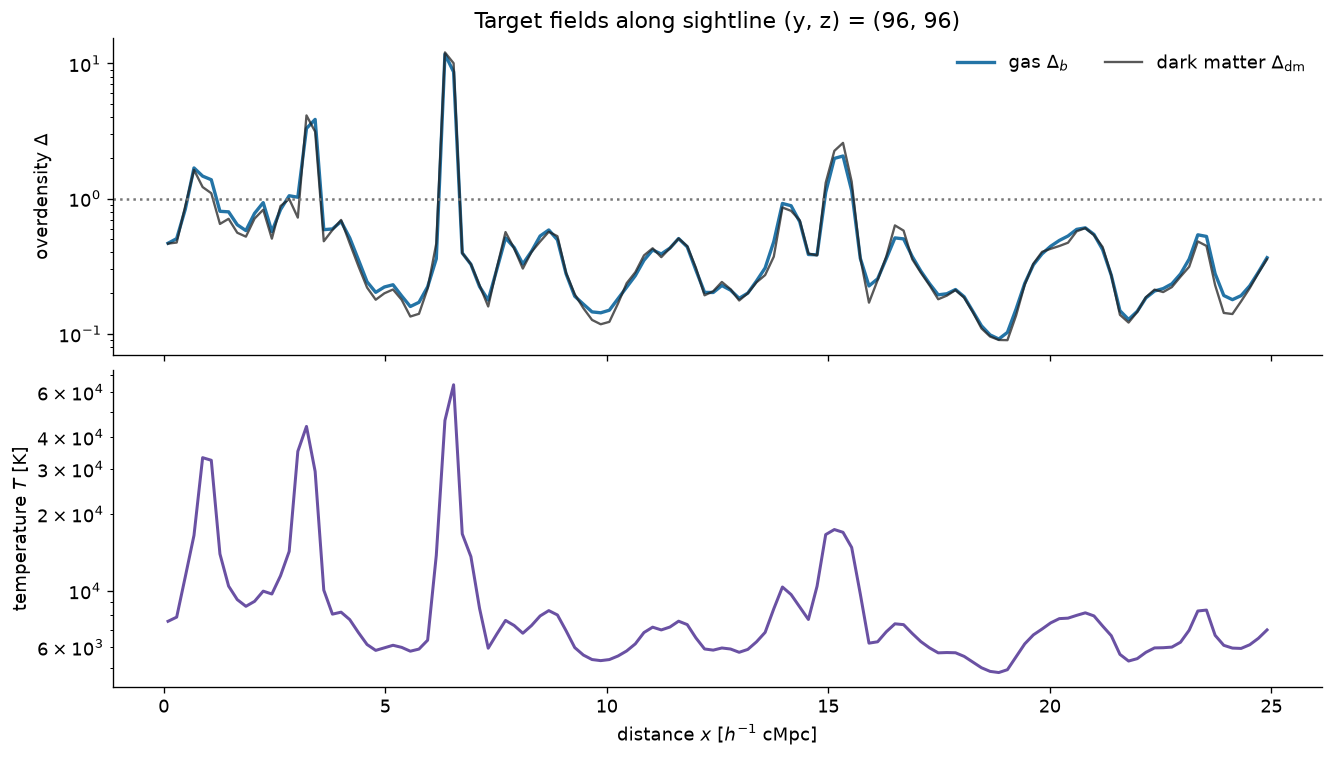

In [81]:
fig, axes = plt.subplots(
    2, 1, figsize=(11, 6.2), sharex=True, constrained_layout=True
)

axes[0].semilogy(x, Delta_b_true, color=BLUE, lw=2.0,
                 label=r"gas $\Delta_b$")
axes[0].semilogy(x, Delta_dm_true, color=BLACK, lw=1.4, alpha=0.75,
                 label=r"dark matter $\Delta_{\rm dm}$")
axes[0].axhline(1.0, color=GREY, ls=":")
axes[0].set_ylabel(r"overdensity $\Delta$")
axes[0].set_title(
    f"Target fields along sightline (y, z) = "
    f"({sightline_index}, {sightline_index})"
)
axes[0].legend(ncol=2)

axes[1].semilogy(x, temperature, color=PURPLE, lw=1.8)
axes[1].set_ylabel(r"temperature $T$ [K]")
axes[1].set_xlabel(r"distance $x$ [$h^{-1}$ cMpc]")
plt.show()

## 4. Measure the low-density temperature–density relation

Photoionized, unshocked IGM gas is approximately described by

$$
T(\Delta_b)=T_0\,\Delta_b^{\gamma-1}.
$$

A raw scatter plot is visually dominated by millions of cells and hides the
occupancy of phase space. The customary alternative is a two-dimensional
logarithmic density map. We then compute the **median temperature in each
logarithmic $\Delta_b$ bin** and fit those medians only over
$0.1\leq\Delta_b\leq2$. This emphasizes the diffuse photoionized sequence and
reduces the leverage of the hot, shock-heated tail.

The fit is performed in log space:

$$
\log_{10}T=\log_{10}T_0+(\gamma-1)\log_{10}\Delta_b.
$$

In [82]:
finite_phase = (
    np.isfinite(Delta_phase)
    & np.isfinite(temperature_phase)
    & (Delta_phase > 0.0)
    & (temperature_phase > 0.0)
)
phase_delta = Delta_phase[finite_phase]
phase_temperature = temperature_phase[finite_phase]

median_edges = np.logspace(np.log10(0.05), np.log10(10.0),
                           eos_number_of_bins + 1)
median_centres = np.sqrt(median_edges[:-1] * median_edges[1:])
median_temperature = np.full(eos_number_of_bins, np.nan)
cells_per_bin = np.zeros(eos_number_of_bins, dtype=int)

bin_number = np.digitize(phase_delta, median_edges) - 1
for index in range(eos_number_of_bins):
    in_bin = bin_number == index
    cells_per_bin[index] = in_bin.sum()
    if cells_per_bin[index] > 0:
        median_temperature[index] = np.median(phase_temperature[in_bin])

fit_bins = (
    np.isfinite(median_temperature)
    & (cells_per_bin >= 100)
    & (median_centres >= eos_delta_min)
    & (median_centres <= eos_delta_max)
)

gamma_minus_one, log10_T0 = np.polyfit(
    np.log10(median_centres[fit_bins]),
    np.log10(median_temperature[fit_bins]),
    1,
)
inversion_T0 = 10.0**log10_T0
inversion_gamma = 1.0 + gamma_minus_one
inversion_beta = 2.0 - 0.7 * (inversion_gamma - 1.0)

print(f"Fit range: {eos_delta_min:.2f} <= Delta_b <= {eos_delta_max:.2f}")
print(f"T0 = {inversion_T0:,.0f} K")
print(f"gamma = {inversion_gamma:.3f}")
print(f"FGPA exponent beta = {inversion_beta:.3f}")

Fit range: 0.10 <= Delta_b <= 2.00
T0 = 11,696 K
gamma = 1.429
FGPA exponent beta = 1.699


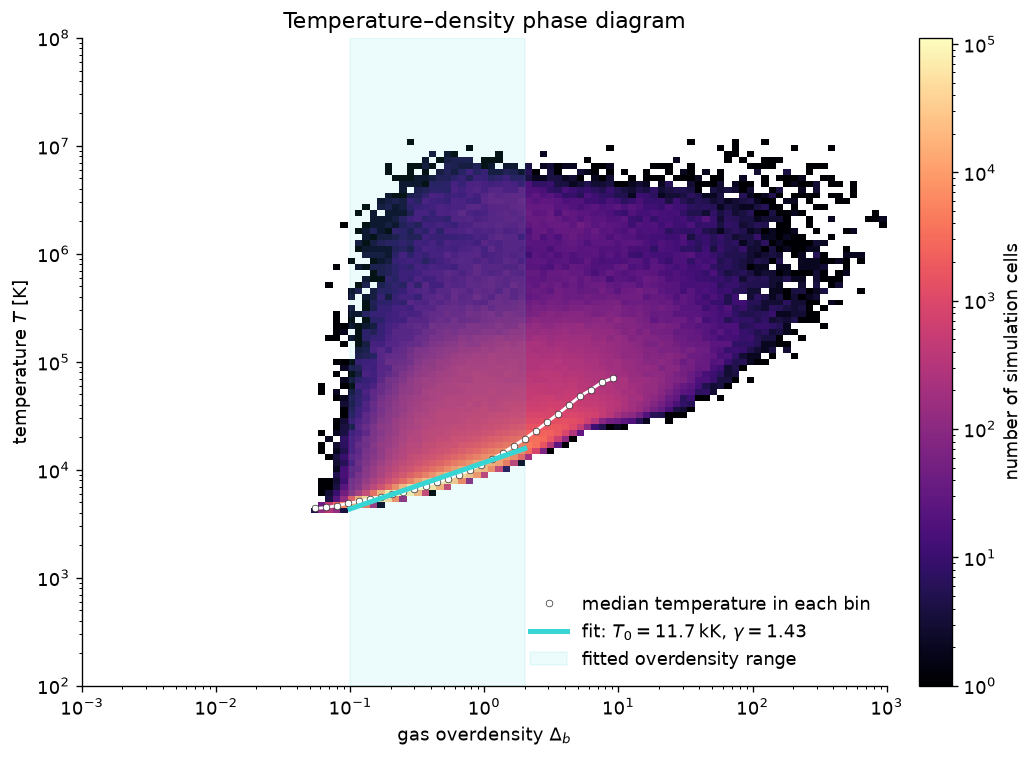

In [83]:
density_edges = np.logspace(-3.0, 3.0, 110)
temperature_edges = np.logspace(2.0, 8.0, 110)

fig, ax = plt.subplots(figsize=(8.5, 6.2), constrained_layout=True)
image = ax.hist2d(
    phase_delta,
    phase_temperature,
    bins=(density_edges, temperature_edges),
    norm=LogNorm(),
    cmap="magma",
    cmin=1,
)
colourbar = fig.colorbar(image[3], ax=ax, pad=0.02)
colourbar.set_label("number of simulation cells")

valid_medians = np.isfinite(median_temperature)
ax.plot(median_centres[valid_medians], median_temperature[valid_medians],
        color="white", lw=1.7, marker="o", ms=4,
        markeredgecolor=BLACK, markeredgewidth=0.4,
        label="median temperature in each bin")

fitted_delta = np.logspace(np.log10(eos_delta_min),
                           np.log10(eos_delta_max), 100)
fitted_temperature = inversion_T0 * fitted_delta**(inversion_gamma - 1.0)
ax.plot(fitted_delta, fitted_temperature, color="#37D5D3", lw=3.0,
        label=rf"fit: $T_0={inversion_T0/1000:.1f}\,$kK, "
              rf"$\gamma={inversion_gamma:.2f}$")

ax.axvspan(eos_delta_min, eos_delta_max, color="#37D5D3", alpha=0.09,
           label="fitted overdensity range")
ax.set(xscale="log", yscale="log",
       xlabel=r"gas overdensity $\Delta_b$",
       ylabel=r"temperature $T$ [K]",
       title="Temperature–density phase diagram")
ax.legend(loc="lower right")
plt.show()

### Checkpoint: what has been fitted?

- The coloured background represents the full gas phase distribution.
- Each white point is a median, not an individual gas cell.
- The cyan line uses only medians between $\Delta_b=0.1$ and $3$.
- $T_0$ is the fitted temperature at mean density; $\gamma-1$ is the log–log slope.

This fit supplies thermal parameters to the inverse. It does **not** replace the
actual cell-by-cell temperature field in the forward calculation.

## 5. Realistic forward model: H I and temperature to flux

For an absorber cell $i$, the thermal Doppler width is

$$b_i=\sqrt{\frac{2k_{\rm B}T_i}{m_{\rm H}}}.$$

Its H I column contributes a Voigt profile to neighbouring spectral pixels. The
resulting optical depth is a sum over all absorber cells. Thus, even before an
instrument is added, $\tau$ at one pixel depends on material in nearby cells.

The calculation below includes Hubble-flow mapping, thermal Doppler broadening,
natural broadening, instrumental smoothing, and Gaussian pixel noise. The supplied
grids do not contain a signed line-of-sight peculiar-velocity field, so redshift-
space distortions from peculiar velocities are explicitly omitted.

In [84]:
# Physical constants in cgs units
MSUN_G = 1.98847e33
MPC_CM = 3.085677581e24
M_H_G = 1.6735575e-24
K_B = 1.380649e-16
C_CMS = 2.99792458e10
C_KMS = C_CMS / 1.0e5

# Ly-alpha atomic constants
LAMBDA_ALPHA_CM = 1215.67e-8
GAMMA_ALPHA = 6.262e8
I_ALPHA = 4.45e-18

H_z = 100.0 * h_camels * np.sqrt(
    Omega_m * (1.0 + box_redshift)**3 + (1.0 - Omega_m)
)
distance_from_centre_Mpc = (x - box_size / 2.0) / h_camels
absorber_redshift = (
    box_redshift + H_z * distance_from_centre_Mpc / C_KMS
)


def hi_grid_to_number_density(rho_hi_grid, redshift):
    '''Convert a CMD H I grid to physical H I number density in cm^-3.'''
    # CMD density unit: (Msun/h)/(Mpc/h)^3 = Msun h^2 / Mpc^3.
    rho_comoving = rho_hi_grid * MSUN_G * h_camels**2 / MPC_CM**3
    rho_physical = rho_comoving * (1.0 + redshift)**3
    return rho_physical / M_H_G


def continuous_voigt_optical_depth(x_comoving, redshift, n_hi, temp):
    '''Sum the continuous, cell-sampled Voigt contribution of every absorber.'''
    nu_alpha = C_CMS / LAMBDA_ALPHA_CM
    x_cm = x_comoving * MPC_CM / h_camels
    cell_width_cm = np.mean(np.diff(x_cm))

    safe_temperature = np.clip(temp, 10.0, None)
    b_cms = np.sqrt(2.0 * K_B * safe_temperature / M_H_G)
    damping = GAMMA_ALPHA * C_CMS / (4.0 * np.pi * nu_alpha * b_cms)

    velocity_offset = (
        C_CMS * (redshift[:, None] - redshift[None, :])
        / (b_cms[:, None] * (1.0 + redshift[None, :]))
    )
    profile = np.real(special.wofz(
        velocity_offset + 1j * damping[:, None]
    ))

    amplitude = (
        C_CMS * I_ALPHA * cell_width_cm * n_hi
        / (np.sqrt(np.pi) * b_cms * (1.0 + redshift))
    )
    return np.sum(amplitude[:, None] * profile, axis=0)

In [85]:
n_HI = hi_grid_to_number_density(rho_HI, absorber_redshift)
optical_depth = continuous_voigt_optical_depth(
    x, absorber_redshift, n_HI, temperature
)

flux_intrinsic = np.exp(-optical_depth)

velocity_pixel_width = H_z * (cell_size / h_camels) / (1.0 + box_redshift)
instrument_sigma_pixels = (
    instrument_fwhm_kms
    / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    / velocity_pixel_width
)
flux_instrument = ndimage.gaussian_filter1d(
    flux_intrinsic, instrument_sigma_pixels, mode="wrap"
)

noise_sigma = 1.0 / signal_to_noise
noise_rng = np.random.default_rng(noise_seed)
flux_observed = flux_instrument + noise_rng.normal(
    0.0, noise_sigma, number_of_cells
)

print(f"Physical n_HI range: {n_HI.min():.3e}--{n_HI.max():.3e} cm^-3")
print(f"Mean intrinsic transmitted flux: {flux_intrinsic.mean():.4f}")
print(f"Velocity width per cell: {velocity_pixel_width:.1f} km/s")
print(f"Instrument sigma: {instrument_sigma_pixels:.2f} pixels")
print(f"Noise sigma_F: {noise_sigma:.4f}")

Physical n_HI range: 4.088e-13--3.687e-07 cm^-3
Mean intrinsic transmitted flux: 0.7609
Velocity width per cell: 19.3 km/s
Instrument sigma: 1.10 pixels
Noise sigma_F: 0.0333


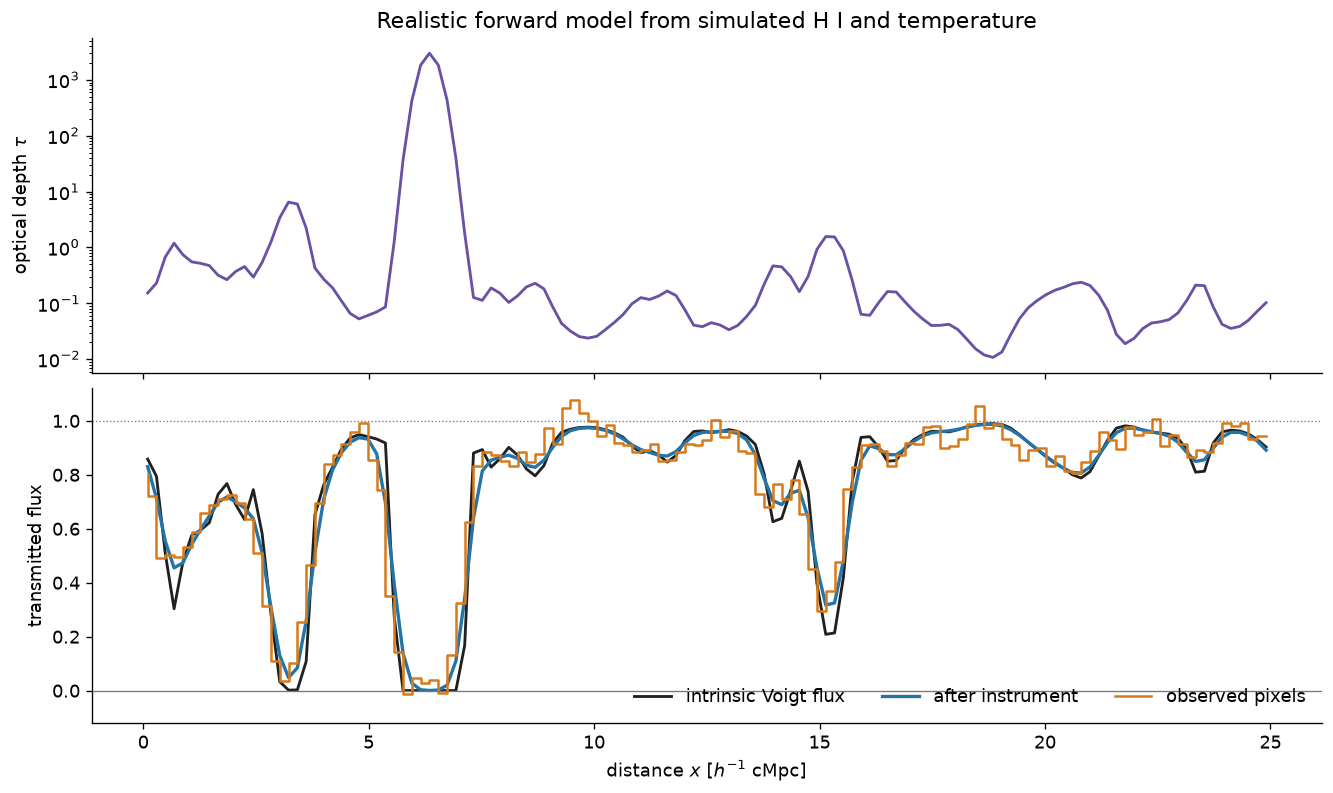

In [86]:
fig, axes = plt.subplots(
    2, 1, figsize=(11, 6.5), sharex=True, constrained_layout=True
)

axes[0].plot(x, optical_depth, color=PURPLE, lw=1.7)
axes[0].set_ylabel(r"optical depth $\tau$")
axes[0].set_yscale("log")
axes[0].set_title("Realistic forward model from simulated H I and temperature")

axes[1].plot(x, flux_intrinsic, color=BLACK, lw=1.7,
             label="intrinsic Voigt flux")
axes[1].plot(x, flux_instrument, color=BLUE, lw=2.0,
             label="after instrument")
axes[1].step(x, flux_observed, color=ORANGE,
                label="observed pixels")
axes[1].axhline(0.0, color=GREY, lw=0.8)
axes[1].axhline(1.0, color=GREY, lw=0.8, ls=":")
axes[1].set_ylim(-0.12, 1.12)
axes[1].set_ylabel("transmitted flux")
axes[1].set_xlabel(r"distance $x$ [$h^{-1}$ cMpc]")
axes[1].legend(ncol=3, loc="lower right")
plt.show()

## 6. The FGPA as an inverse model

In optically thin photoionization equilibrium,

$$
n_{\rm HI}\propto \rho_b^2\,T^{-0.7}\,\Gamma_{\rm HI}^{-1}.
$$

Combining this with $T=T_0\Delta_b^{\gamma-1}$ gives the local approximation

$$
\tau_{\rm FGPA}=A
\left(\frac{T_0}{10^4\,{\rm K}}\right)^{-0.7}
\Delta_b^\beta,
\qquad
\beta=2-0.7(\gamma-1).
$$

If $F=e^{-\tau}$ and there is no broadening or noise, the algebraic inverse is

$$
\boxed{\Delta_b=
\left[
\frac{-\ln F}
{A(T_0/10^4\,{\rm K})^{-0.7}}
\right]^{1/\beta}}.
$$

This inverse is local; the realistic Voigt forward model is not. The mismatch
already guarantees that the inverse cannot be exact.

## 7. Calibrate the effective FGPA normalization

The amplitude $A$ is degenerate with the ionizing background, cosmology, and
mean-density normalization. Here it is treated as an effective nuisance parameter.
We determine it by matching the mean flux of several realistic calibration
skewers from the same simulation box, excluding the target line of sight.


In [87]:
temperature_factor = (inversion_T0 / 1.0e4)**(-0.7)

calibration_shape = []
calibration_flux = []

calibration_positions = [
    (16, 16), (16, 48), (16, 80), (16, 112),
    (48, 16), (48, 48), (48, 80), (48, 112),
    (80, 16), (80, 48), (80, 80), (112, 112),
]

for y_cal, z_cal in calibration_positions:
    delta_cal = (
        gas_boxes[simulation_index, :, y_cal, z_cal].astype(float)
        / gas_mean
    )
    temperature_cal = temperature_boxes[
        simulation_index, :, y_cal, z_cal
    ].astype(float)
    rho_hi_cal = hi_boxes[
        simulation_index, :, y_cal, z_cal
    ].astype(float)
    n_hi_cal = hi_grid_to_number_density(rho_hi_cal, absorber_redshift)
    tau_cal = continuous_voigt_optical_depth(
        x, absorber_redshift, n_hi_cal, temperature_cal
    )
    calibration_flux.append(np.exp(-tau_cal))
    calibration_shape.append(
        temperature_factor * delta_cal**inversion_beta
    )

calibration_flux = np.concatenate(calibration_flux)
calibration_shape = np.concatenate(calibration_shape)
calibration_mean_flux = calibration_flux.mean()

def mean_flux_difference(log_amplitude):
    amplitude = np.exp(log_amplitude)
    fgpa_mean_flux = np.mean(np.exp(-amplitude * calibration_shape))
    return fgpa_mean_flux - calibration_mean_flux

log_A_fgpa = brentq(mean_flux_difference, -20.0, 20.0)
A_fgpa = np.exp(log_A_fgpa)

print(f"Calibration skewers: {len(calibration_flux) // number_of_cells}")
print(f"Realistic-mock mean flux: {calibration_mean_flux:.4f}")
print(f"Effective FGPA amplitude A: {A_fgpa:.5f}")
print(f"Thermal factor (T0/10^4 K)^-0.7: {temperature_factor:.3f}")

Calibration skewers: 12
Realistic-mock mean flux: 0.6769
Effective FGPA amplitude A: 1.20780
Thermal factor (T0/10^4 K)^-0.7: 0.896


## 8. Stabilize the inverse and identify censored pixels

The logarithm requires $0<F<1$. Noise can produce values outside this interval,
but merely clipping them does not restore lost information.

We define a conservative two-sigma non-detection threshold

$$F_{\rm floor}=\max(0.02,2\sigma_F).$$

Pixels at or below this floor are treated as saturated/censored. The inversion
then returns only

$$
\Delta_b\geq\Delta_{\rm sat,min}
=\left[
\frac{-\ln F_{\rm floor}}
{A(T_0/10^4\,{\rm K})^{-0.7}}
\right]^{1/\beta}.
$$

Every still-denser absorber maps to the same plotted lower limit. Saturation is
therefore an information problem, not a numerical bug.

In [88]:
flux_floor = max(minimum_flux_floor, 2.0 * noise_sigma)
flux_ceiling = 1.0 - 1.0e-5


def invert_flux_with_fgpa(flux, floor=flux_floor, ceiling=flux_ceiling):
    '''Local FGPA inverse with explicit finite-flux limits.'''
    safe_flux = np.clip(flux, floor, ceiling)
    recovered_tau = -np.log(safe_flux)
    denominator = A_fgpa * temperature_factor
    return (recovered_tau / denominator)**(1.0 / inversion_beta)


# The intrinsic result isolates forward/inverse model mismatch.
Delta_fgpa_intrinsic = invert_flux_with_fgpa(
    flux_intrinsic, floor=1.0e-8, ceiling=1.0 - 1.0e-8
)

# The observed result also includes finite resolution, noise, and clipping.
Delta_fgpa_observed = invert_flux_with_fgpa(flux_observed)

saturated_pixels = flux_observed <= flux_floor
continuum_limited_pixels = flux_observed >= flux_ceiling
Delta_saturation_lower_limit = invert_flux_with_fgpa(
    np.array([flux_floor])
)[0]

print(f"Adopted flux floor: {flux_floor:.4f}")
print(f"Saturated/censored pixels: {saturated_pixels.sum()} / {number_of_cells}")
print(f"Pixels at the continuum ceiling: "
      f"{continuum_limited_pixels.sum()} / {number_of_cells}")
print(f"Saturation implies only Delta_b >= "
      f"{Delta_saturation_lower_limit:.2f}")

Adopted flux floor: 0.0667
Saturated/censored pixels: 6 / 128
Pixels at the continuum ceiling: 6 / 128
Saturation implies only Delta_b >= 1.72


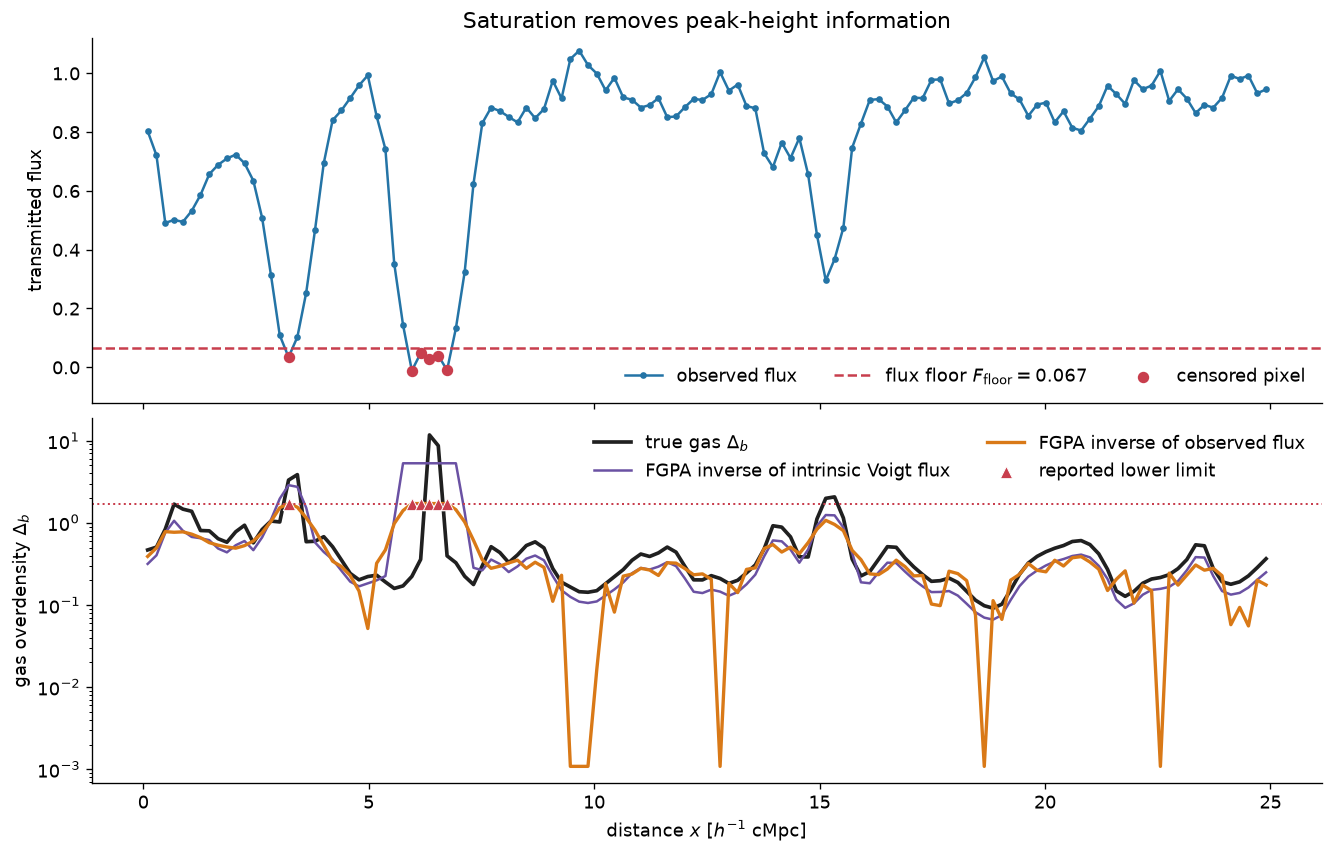

In [89]:
fig, axes = plt.subplots(
    2, 1, figsize=(11, 7.0), sharex=True, constrained_layout=True
)

axes[0].plot(x, flux_observed, color=BLUE, lw=1.5, marker="o", ms=3,
             label="observed flux")
axes[0].axhline(flux_floor, color=RED, ls="--",
                label=rf"flux floor $F_{{\rm floor}}={flux_floor:.3f}$")
axes[0].scatter(x[saturated_pixels], flux_observed[saturated_pixels],
                color=RED, s=34, zorder=4, label="censored pixel")
axes[0].set_ylim(-0.12, 1.12)
axes[0].set_ylabel("transmitted flux")
axes[0].set_title("Saturation removes peak-height information")
axes[0].legend(ncol=3)

axes[1].semilogy(x, Delta_b_true, color=BLACK, lw=2.2,
                 label=r"true gas $\Delta_b$")
axes[1].semilogy(x, Delta_fgpa_intrinsic, color=PURPLE, lw=1.5,
                 label="FGPA inverse of intrinsic Voigt flux")
axes[1].semilogy(x, Delta_fgpa_observed, color=ORANGE, lw=2.0,
                 label="FGPA inverse of observed flux")
axes[1].scatter(
    x[saturated_pixels], Delta_fgpa_observed[saturated_pixels],
    marker="^", s=55, facecolor=RED, edgecolor="white", linewidth=0.6,
    zorder=5, label="reported lower limit"
)
axes[1].axhline(Delta_saturation_lower_limit, color=RED, ls=":", lw=1.2)
axes[1].set_ylabel(r"gas overdensity $\Delta_b$")
axes[1].set_xlabel(r"distance $x$ [$h^{-1}$ cMpc]")
axes[1].legend(ncol=2)
plt.show()

### Read the reconstruction figure in two comparisons

1. **Black versus purple:** failure caused by applying a local FGPA inverse to a
   non-local Voigt spectrum, even before observational degradation.
2. **Purple versus orange:** additional loss caused by instrumental smoothing,
   noise, and the finite flux floor.

Upward triangles are not ordinary point estimates. They mean “the density is at
least this large under the assumed FGPA parameters.” The true peak may be much
higher, and the spectrum alone cannot determine its height once the absorption is
saturated.

## 9. Validate at matched resolution

Comparing a blurred reconstruction with unsmoothed cell-scale truth unfairly
assigns instrumental information loss to the inverse. We therefore smooth both
fields to a common $1\,h^{-1}{\rm cMpc}$ FWHM before reporting primary metrics.

We use log-density errors because Lyα forest densities span orders of magnitude:

$$
{\rm RMSE}_{\log\Delta}
=\sqrt{\left\langle
(\log_{10}\Delta_{\rm rec}-\log_{10}\Delta_{\rm true})^2
\right\rangle}.
$$

In [90]:
comparison_sigma_pixels = (
    comparison_fwhm
    / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    / cell_size
)


def smooth_for_comparison(field):
    return ndimage.gaussian_filter1d(
        field, comparison_sigma_pixels, mode="wrap"
    )


def log_field_metrics(truth, estimate):
    log_truth = np.log10(np.clip(truth, 1.0e-4, None))
    log_estimate = np.log10(np.clip(estimate, 1.0e-4, None))
    difference = log_estimate - log_truth
    return {
        "correlation": np.corrcoef(log_truth, log_estimate)[0, 1],
        "rmse_dex": np.sqrt(np.mean(difference**2)),
        "bias_dex": np.mean(difference),
    }


Delta_b_true_matched = smooth_for_comparison(Delta_b_true)
Delta_b_recovered_matched = smooth_for_comparison(Delta_fgpa_observed)
baryon_metrics = log_field_metrics(
    Delta_b_true_matched, Delta_b_recovered_matched
)

print(f"Comparison FWHM: {comparison_fwhm:.2f} h^-1 cMpc")
print(f"log-density correlation: {baryon_metrics['correlation']:.3f}")
print(f"log-density RMSE: {baryon_metrics['rmse_dex']:.3f} dex")
print(f"log-density bias: {baryon_metrics['bias_dex']:+.3f} dex")

Comparison FWHM: 1.00 h^-1 cMpc
log-density correlation: 0.944
log-density RMSE: 0.173 dex
log-density bias: -0.136 dex


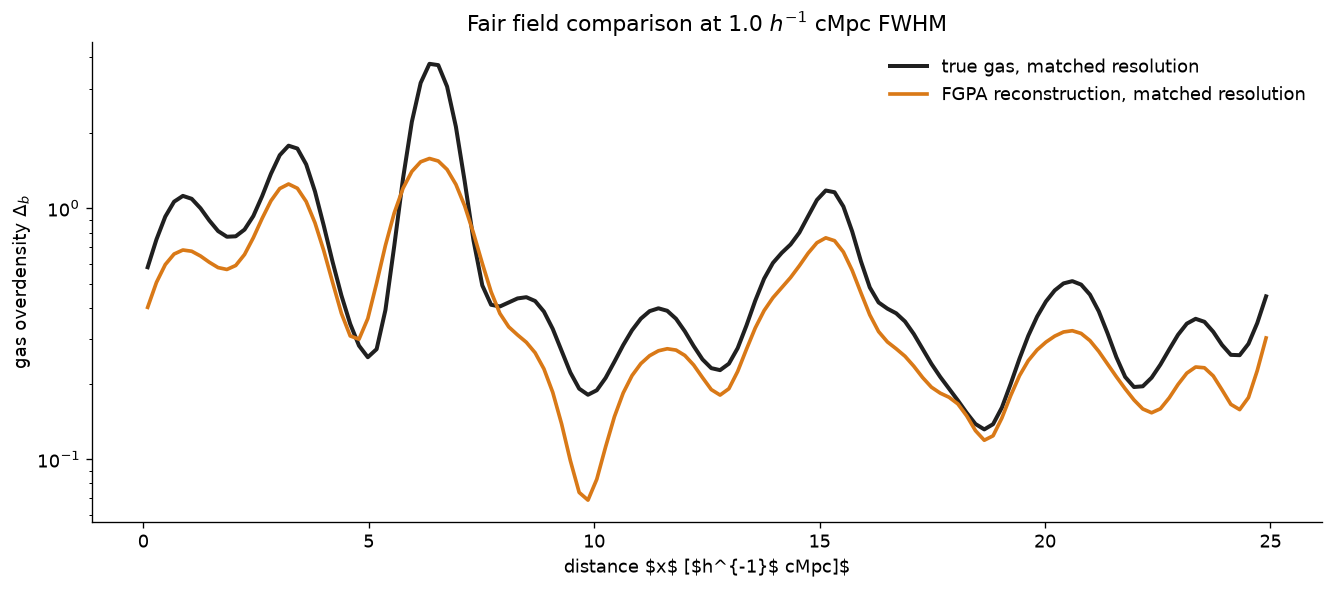

In [91]:
fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
ax.semilogy(x, Delta_b_true_matched, color=BLACK, lw=2.4,
            label="true gas, matched resolution")
ax.semilogy(x, Delta_b_recovered_matched, color=ORANGE, lw=2.2,
            label="FGPA reconstruction, matched resolution")
ax.set(xlabel=r"distance $x$ [$h^{-1}$ cMpc]$",
       ylabel=r"gas overdensity $\Delta_b$",
       title=rf"Fair field comparison at {comparison_fwhm:.1f} $h^{{-1}}$ cMpc FWHM")
ax.legend()
plt.show()

## 10. From baryons to a dark-matter proxy

FGPA inversion targets the baryonic density. Calling the result “dark matter”
requires the additional approximation

$$\Delta_{\rm dm}^{\rm proxy}(x)\equiv\Delta_b^{\rm FGPA}(x).$$

We therefore report two errors separately:

- **inversion error:** reconstructed gas versus true gas;
- **tracer error:** reconstructed gas used as a proxy for true dark matter.

Combining them into one score would obscure which physical assumption failed.

In [92]:
Delta_dm_true_matched = smooth_for_comparison(Delta_dm_true)
Delta_dm_proxy_matched = Delta_b_recovered_matched.copy()

dm_proxy_metrics = log_field_metrics(
    Delta_dm_true_matched, Delta_dm_proxy_matched
)

print("Baryon reconstruction")
print(f"  r = {baryon_metrics['correlation']:.3f}, "
      f"RMSE = {baryon_metrics['rmse_dex']:.3f} dex")
print("Dark-matter proxy")
print(f"  r = {dm_proxy_metrics['correlation']:.3f}, "
      f"RMSE = {dm_proxy_metrics['rmse_dex']:.3f} dex")

Baryon reconstruction
  r = 0.944, RMSE = 0.173 dex
Dark-matter proxy
  r = 0.942, RMSE = 0.169 dex


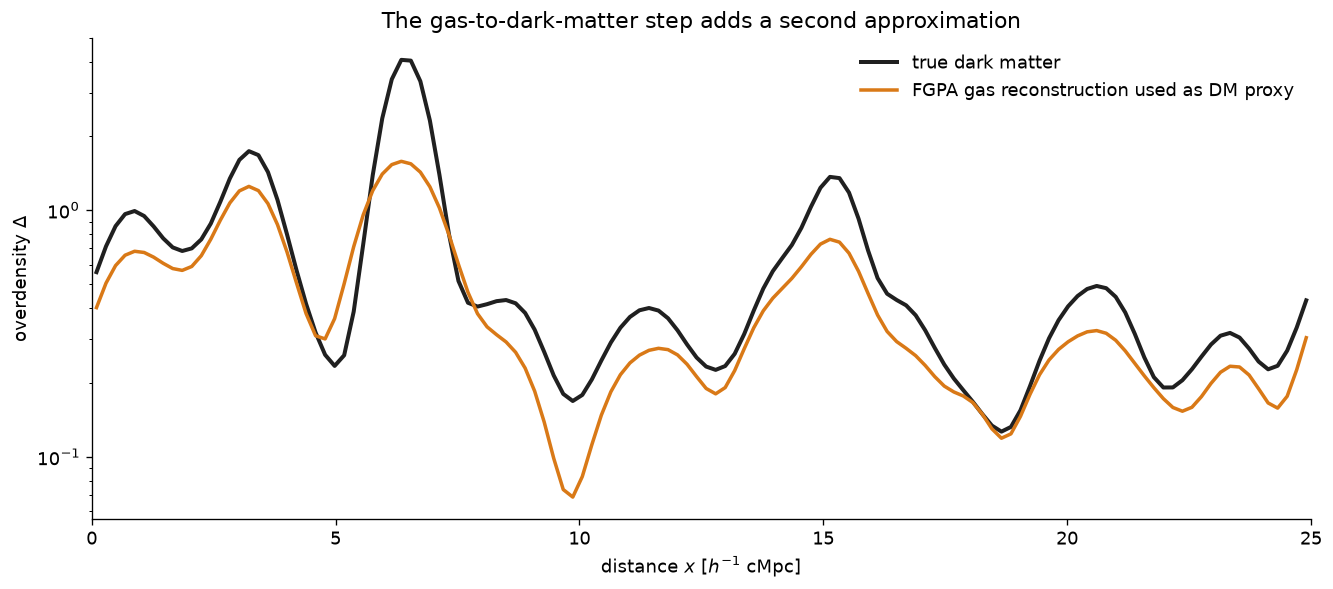

In [93]:
fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
ax.semilogy(x, Delta_dm_true_matched, color=BLACK, lw=2.4,
            label="true dark matter")
ax.semilogy(x, Delta_dm_proxy_matched, color=ORANGE, lw=2.1,
            label="FGPA gas reconstruction used as DM proxy")
ax.set(xlabel=r"distance $x$ [$h^{-1}$ cMpc]",
       ylabel=r"overdensity $\Delta$",
       title="The gas-to-dark-matter step adds a second approximation")
ax.set_xlim(0.0, box_size)
ax.legend()
plt.show()

## 12. What this experiment establishes

| Observation | Physical interpretation |
|---|---|
| FGPA recovers part of the large-scale pattern | Lyα absorption is strongly correlated with diffuse gas density |
| Intrinsic-Voigt inversion is already imperfect | the real forward map is broadened and non-local, unlike local FGPA |
| Observational inversion is worse | finite resolution and noise remove additional information |
| Saturated pixels collapse to one lower limit | peak heights are not identifiable from black absorption alone |
| Gas and dark matter disagree further | baryon-to-DM conversion is a separate modelling assumption |

The traditional algebraic FGPA inversion is therefore a valuable baseline, but
not an optimal reconstruction method. It has no mechanism for non-local line
formation, correlated priors, uncertainty propagation, or inference of peak
heights hidden by saturation. Classical iterative or Bayesian reconstructions—and
later neural networks—attempt to use neighbouring pixels and learned or explicit
priors to address some of these limitations. No method can recover information
that is absent without introducing such prior information.

## 13. Assumptions and omissions

- **Thermal relation:** a single power law summarizes only the cool diffuse IGM;
  shock-heated and multiphase gas do not obey it.
- **Ionizing background:** $A$ is calibrated as an effective parameter. A spatially
  fluctuating UV background is not modelled.
- **Velocities:** Hubble flow is included, but signed peculiar velocities are absent
  because they are not supplied by these grids.
- **Instrument:** the line-spread function is Gaussian and spatially invariant.
- **Noise:** pixel noise is independent and Gaussian; continuum uncertainty and
  metal contamination are omitted.
- **Gridding:** a cell-sampled continuous Voigt sum is pedagogically transparent,
  but not a complete survey spectral pipeline.
- **Saturation:** the clipped reconstruction is explicitly a lower limit; it should
  not be interpreted as an unbiased density estimate.